# Árboles de Modelos M5 (M5 y M5')

**Descripción:**

M5 es un algoritmo de **árbol de modelos** (*model tree*) propuesto por Quinlan (1992) para problemas de **regresión** (variable objetivo continua), pensado como una extensión de los árboles de decisión tipo CART al caso continuo. Al igual que un árbol de regresión clásico, M5 particiona recursivamente el espacio de atributos eligiendo en cada nodo el atributo y umbral que más reduce la dispersión del objetivo — el criterio de partición es la **reducción de la desviación estándar** (*Standard Deviation Reduction*, SDR), análogo a la reducción de varianza que usa CART para regresión. La diferencia clave está en las hojas: en vez de predecir una **constante** (el promedio del subconjunto, como hace CART), cada hoja de M5 ajusta un **modelo de regresión lineal multivariante** sobre los atributos relevantes de esa región, produciendo predicciones **lineales por tramos** (*piecewise-linear*) en vez de una función escalonada. Wang y Witten (1997) refinaron el algoritmo original bajo el nombre **M5'** (M5-Prime), mejorando el manejo de atributos nominales y de valores faltantes, y añadiendo una fase de **suavizado** (*smoothing*) que combina el modelo de cada hoja con los de sus nodos ancestros para evitar discontinuidades bruscas en la frontera entre regiones.

**Bibtex y Referencias:**

```bibtex
@inproceedings{quinlan1992learning,
  title={Learning with continuous classes},
  author={Quinlan, J. Ross},
  booktitle={5th Australian Joint Conference on Artificial Intelligence},
  volume={92},
  pages={343--348},
  year={1992},
  organization={World Scientific}
}

@inproceedings{wang1997inducing,
  title={Induction of model trees for predicting continuous classes},
  author={Wang, Yong and Witten, Ian H.},
  booktitle={Poster papers of the 9th European Conference on Machine Learning},
  year={1997},
  publisher={Springer}
}

@misc{marie2022m5py,
  title={python-m5p: M5 and Model Trees in Python, scikit-learn compliant},
  author={Mari\'e, Sylvain},
  howpublished={GitHub},
  url={https://github.com/smarie/python-m5p},
  year={2022}
}
```

**Tipo de Modelo:**
- **Método de aprendizaje:** Aprendizaje supervisado — **regresión** de variable continua (a diferencia de C4.5/C5.0, que son de clasificación)
- **Por parámetros:** No paramétrico — la complejidad del árbol (profundidad, número de hojas, número de modelos lineales) crece con los datos
- **Datos de aprendizaje:** Aprendizaje por lotes (*batch*/offline) sobre datos etiquetados con un objetivo continuo
- **Resultado del entrenamiento:** Aprendizaje basado en modelo (*eager learning*) — produce una estructura de árbol explícita, con un modelo de regresión lineal interpretable en cada hoja

**Alg. Entrenamiento:**
- Inducción descendente por partición recursiva voraz (TDIDT), igual que CART: en cada nodo se elige el atributo/umbral que maximiza la reducción de desviación estándar (SDR) del objetivo, repitiendo sobre cada subconjunto hasta un criterio de parada.
- A diferencia de CART, tras crecer el árbol se ajusta un **modelo de regresión lineal por hoja**, usando solo los atributos que aparecieron en las particiones de esa rama.
- **Poda posterior** (*pruning*): se colapsan subárboles cuyo modelo lineal combinado no mejora significativamente el error estimado frente al de un único modelo lineal en el nodo padre.
- **Suavizado** (*smoothing*, introducido por M5'): la predicción final de una hoja se combina recursivamente con los modelos lineales de sus nodos ancestros (ponderando por el número de instancias de entrenamiento), lo que reduce discontinuidades entre regiones vecinas del árbol.

**Supuestos y Restricciones:**
- Asume que la relación entre atributos y objetivo puede aproximarse **localmente** (dentro de cada región/hoja) mediante una función lineal, aunque globalmente sea no lineal — es un punto intermedio entre un único modelo lineal global y un árbol de regresión puramente constante por tramos.
- Sensible a valores atípicos dentro de una hoja (afectan al ajuste de la regresión lineal local) y al ruido, igual que cualquier árbol de partición recursiva.
- **scikit-learn no implementa M5/M5' de forma nativa** — su `DecisionTreeRegressor` es CART puro (predicción constante en cada hoja, sin gain ratio ni SDR ni modelos lineales). Aquí usamos el paquete de terceros **`m5py`**, que sí implementa M5' fielmente sobre el motor de árboles de scikit-learn (ver advertencias en la siguiente celda).
- `m5py` maneja de forma nativa solo atributos **numéricos**; los atributos categóricos deben codificarse primero (igual que con CART), a diferencia de lo que promete la especificación original de M5' para nominales.

# Árboles de Modelos M5: M5' con `m5py`

**Advertencia importante antes de empezar:** el `DecisionTreeRegressor` de scikit-learn implementa **CART** para regresión — particiona el espacio y predice la **media** del subconjunto en cada hoja. No es M5 ni M5'. Para M5 sí existe una implementación de terceros razonablemente fiel: **[`m5py`](https://github.com/smarie/python-m5p)** (paquete `python-m5p` de Sylvain Marié), que reutiliza el motor de árboles de scikit-learn pero añade modelos lineales por hoja, poda y suavizado siguiendo el algoritmo M5' de Wang y Witten. No es un paquete oficial de scikit-learn ni tiene el respaldo/mantenimiento de una librería central — trátalo como una herramienta de investigación/docencia, no de producción crítica.

| | **CART regresión** (`DecisionTreeRegressor`, sklearn) | **M5'** (`M5Prime`, `m5py`) |
|---|---|---|
| Predicción en la hoja | Constante (media del subconjunto) | Modelo de regresión lineal multivariante |
| Criterio de partición | Reducción de varianza / MSE | Reducción de desviación estándar (SDR) — equivalente conceptual |
| Forma de la predicción | Función escalonada (discontinua) | Aproximadamente lineal por tramos |
| Poda | Por complejidad de costo (`ccp_alpha`) | Poda basada en error estimado por subárbol |
| Suavizado entre regiones | No | Sí — combina la hoja con sus ancestros (`use_smoothing`) |
| Atributos | Numéricos + categóricos codificados | Numéricos (categóricos deben codificarse) |
| Licencia / estado en Python | Oficial, incluido en scikit-learn | Paquete de terceros (`m5py`), mantenimiento limitado |

Para ilustrar estas diferencias usamos el dataset **California Housing** (`sklearn.datasets.fetch_california_housing`): ~20 600 distritos censales de California descritos por 8 variables **numéricas continuas** (ingreso medio del distrito, antigüedad media de las viviendas, habitaciones/dormitorios promedio, población, ocupación promedio, latitud/longitud), con el objetivo de predecir el **valor medio de vivienda** del distrito (en cientos de miles de USD). Al ser un problema de regresión con variables ya numéricas, no hace falta codificación categórica y podemos concentrarnos en la diferencia real entre CART y M5': predicción constante vs. modelo lineal por hoja.

**Requisitos:** `numpy`, `pandas`, `matplotlib`, `scikit-learn` (preinstalados en Google Colab) + **`m5py`**, que instalamos en la siguiente celda. `m5py` no se ha actualizado desde 2022 y depende de una API interna de scikit-learn (`sklearn.tree._classes.DTYPE`, y una validación de parámetros de `plot_tree` menos estricta) que versiones más recientes de scikit-learn eliminaron o endurecieron, así que fijamos `scikit-learn==1.2.2` explícitamente — `pip` se encarga de bajar también `numpy` a una versión compatible con esa versión de scikit-learn. Si Colab ya había importado scikit-learn en esta sesión antes de instalar la versión fijada, reinicia el entorno de ejecución (*Entorno de ejecución → Reiniciar sesión*) después de instalar y antes de correr el resto del notebook.

In [1]:
!pip install -q "scikit-learn==1.2.2" m5py


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from m5py import M5Prime, export_text_m5

np.random.seed(42)  # reproducibilidad

## 1. Cargar datos de ejemplo

Usamos el dataset **California Housing**, incluido directamente en scikit-learn (no requiere descargarlo de OpenML): 20 640 distritos censales descritos por 8 atributos numéricos continuos (`MedInc`: ingreso medio, `HouseAge`: antigüedad media de la vivienda, `AveRooms`/`AveBedrms`: habitaciones/dormitorios promedio por hogar, `Population`, `AveOccup`: ocupación promedio, `Latitude`/`Longitude`), con el objetivo `MedHouseVal` (valor medio de vivienda del distrito, en cientos de miles de USD). Todas las variables son numéricas y no hay valores faltantes — un dataset "limpio" que deja ver con claridad la diferencia entre una hoja constante (CART) y una hoja con regresión lineal (M5').

In [3]:
housing = fetch_california_housing(as_frame=True)

X_raw = housing.data
y_raw = housing.target  # MedHouseVal: valor medio de vivienda (en cientos de miles de USD)
feature_names = X_raw.columns.tolist()

df_preview = X_raw.copy()
df_preview["MedHouseVal"] = y_raw
df_preview.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Explorar las variables

`DecisionTreeRegressor` y `M5Prime` solo aceptan números; las 8 variables de este dataset **ya son numéricas**, así que no hace falta codificación one-hot. Antes de entrenar, revisamos su escala y su correlación lineal con el objetivo — esto además nos da una intuición de qué variables es más probable que aparezcan tanto en las particiones del árbol como en los coeficientes de los modelos lineales de las hojas.

In [4]:
X = X_raw.values
y = y_raw.values  # m5py indexa internamente por posición; conviene pasar arrays de numpy, no Series de pandas

print(f"Variables: {X_raw.shape[1]} (todas numéricas, sin codificación necesaria)")
X_raw.describe().T[["mean", "std", "min", "max"]]

Variables: 8 (todas numéricas, sin codificación necesaria)


,mean,std,min,max
MedInc,3.870671,1.899822,0.499900,15.000100
HouseAge,28.639486,12.585558,1.000000,52.000000
AveRooms,5.429000,2.474173,0.846154,141.909091
AveBedrms,1.096675,0.473911,0.333333,34.066667
Population,1425.476744,1132.462122,3.000000,35682.000000
AveOccup,3.070655,10.386050,0.692308,1243.333333
Latitude,35.631861,2.135952,32.540000,41.950000
Longitude,-119.569704,2.003532,-124.350000,-114.310000


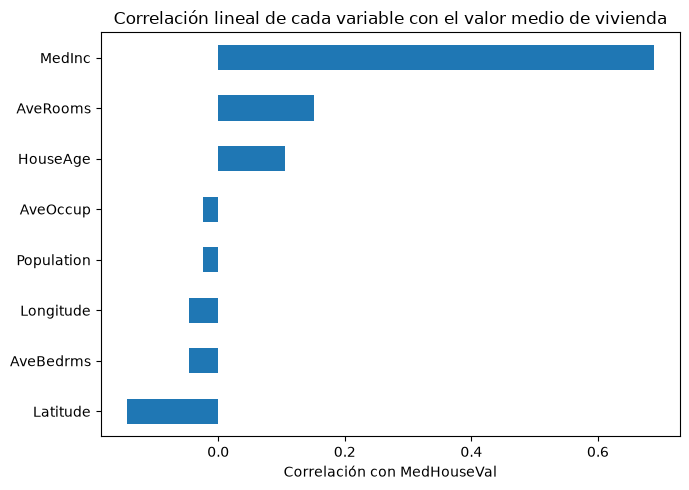

In [5]:
correlaciones = X_raw.corrwith(y_raw).sort_values()

plt.figure(figsize=(7, 5))
correlaciones.plot(kind="barh")
plt.xlabel("Correlación con MedHouseVal")
plt.title("Correlación lineal de cada variable con el valor medio de vivienda")
plt.tight_layout()
plt.show()

## 3. Dividir los datos

Igual que con árboles de clasificación, no hace falta escalar las variables para las **particiones** del árbol (son invariantes a la escala). Sí vale la pena tenerlo presente para los **modelos lineales de las hojas** de M5': sus coeficientes están en la escala original de cada variable (p. ej. el coeficiente de `Population`, que va de cientos a miles, será mucho más pequeño en magnitud que el de `MedInc`, que va de 0 a ~15) — no hay que confundir la magnitud del coeficiente con la importancia de la variable.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 16512 muestras | Prueba: 4128 muestras


## 4. Entrenar un árbol de modelos M5' (`M5Prime`)

`M5Prime` sigue la API de scikit-learn (`fit`/`predict`, `get_depth()`, `get_n_leaves()`, `feature_importances_`), así que se usa igual que un `DecisionTreeRegressor`. Por defecto crece el árbol sin restricción de profundidad y luego aplica poda (`use_pruning=True`) y suavizado (`use_smoothing=True`) — la sección 9 explora qué pasa si se desactivan.

In [7]:
m5_tree = M5Prime(random_state=42)
m5_tree.fit(X_train, y_train)

y_pred_m5 = m5_tree.predict(X_test)
rmse_m5 = np.sqrt(mean_squared_error(y_test, y_pred_m5))
mae_m5 = mean_absolute_error(y_test, y_pred_m5)
r2_m5 = r2_score(y_test, y_pred_m5)

print(f"RMSE: {rmse_m5:.3f} | MAE: {mae_m5:.3f} | R²: {r2_m5:.3f}")
print(f"Profundidad del árbol: {m5_tree.get_depth()}, hojas (modelos lineales): {m5_tree.get_n_leaves()}")

RMSE: 0.577 | MAE: 0.358 | R²: 0.746
Profundidad del árbol: 27, hojas (modelos lineales): 3052


## 5. Visualizar el árbol de modelos

`plot_tree` funciona sobre `M5Prime` porque hereda el motor de árboles de scikit-learn, pero solo dibuja la **estructura de particiones** — no muestra los modelos lineales de las hojas. Para ver esos modelos usamos `export_text_m5`, la función propia de `m5py` que imprime tanto el árbol como la fórmula de cada hoja. Como el árbol completo tiene miles de hojas (ver sección anterior), entrenamos aquí una copia limitada a profundidad 3 **solo para que la visualización sea legible** — el modelo con el que medimos precisión sigue siendo el de la sección 4.

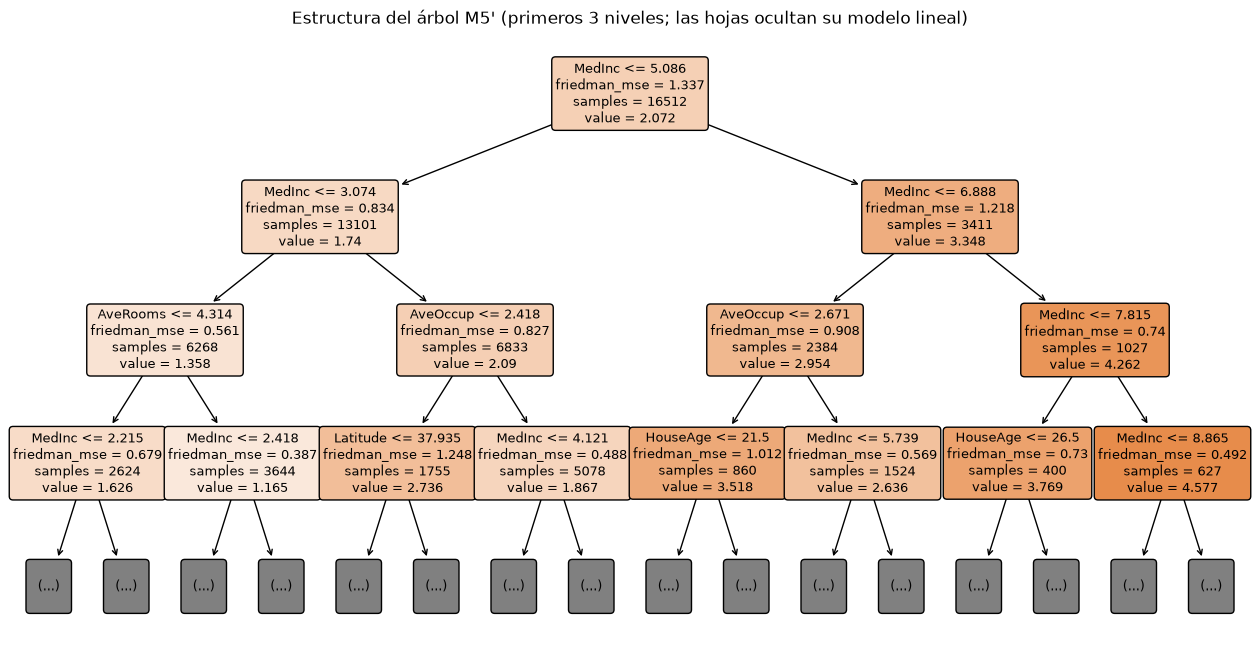

In [8]:
plt.figure(figsize=(16, 8))
plot_tree(
    m5_tree,
    feature_names=feature_names,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Estructura del árbol M5' (primeros 3 niveles; las hojas ocultan su modelo lineal)")
plt.show()

In [9]:
m5_demo = M5Prime(max_depth=3, random_state=42)
m5_demo.fit(X_train, y_train)

print(export_text_m5(m5_demo, out_file=None, feature_names=feature_names))

M5Prime (pre-smoothed with constant 15):

MedInc <= 5.086 [friedman_mse=1.337, samples=16512] (err=0.785, params=39)
|   MedInc <= 3.074 [friedman_mse=0.834, samples=13101] (err=0.774, params=19)
|   |   AveRooms <= 4.314 [friedman_mse=0.561, samples=6268] (err=0.713, params=9)
|   |   |   LEAF [friedman_mse=0.679, samples=2624] : LM1 (err=0.824, params=4)
|   |   |   LEAF [friedman_mse=0.387, samples=3644] : LM2 (err=0.622, params=4)
|   |   AveOccup <= 2.418 [friedman_mse=0.827, samples=6833] (err=0.826, params=9)
|   |   |   LEAF [friedman_mse=1.248, samples=1755] : LM3 (err=1.117, params=4)
|   |   |   LEAF [friedman_mse=0.488, samples=5078] : LM4 (err=0.698, params=4)
|   MedInc <= 6.888 [friedman_mse=1.218, samples=3411] (err=0.826, params=19)
|   |   AveOccup <= 2.671 [friedman_mse=0.908, samples=2384] (err=0.853, params=9)
|   |   |   LEAF [friedman_mse=1.012, samples=860] : LM5 (err=1.005, params=4)
|   |   |   LEAF [friedman_mse=0.569, samples=1524] : LM6 (err=0.754, params=4

## 6. Predicho vs. real

En regresión no hay matriz de confusión: el diagnóstico equivalente es comparar el valor **predicho** contra el **real** para cada muestra de prueba. Una nube de puntos pegada a la diagonal indica buen ajuste; una nube dispersa o con forma de abanico indica error sistemático o heterocedasticidad.

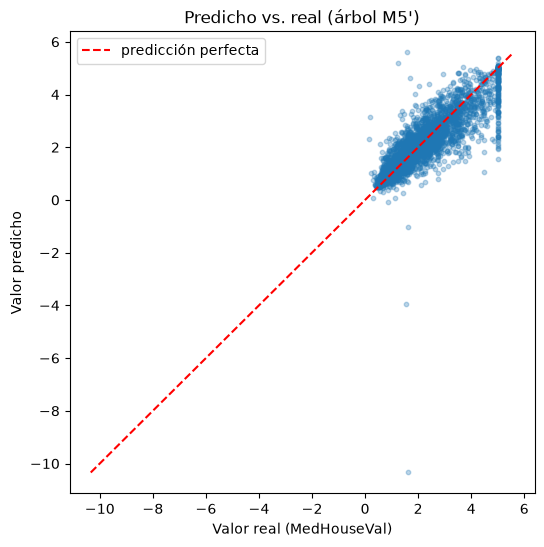

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_m5, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_m5.min()), max(y_test.max(), y_pred_m5.max())]
plt.plot(lims, lims, "r--", label="predicción perfecta")
plt.xlabel("Valor real (MedHouseVal)")
plt.ylabel("Valor predicho")
plt.title("Predicho vs. real (árbol M5')")
plt.legend()
plt.show()

## 7. Importancia de variables

`feature_importances_` en `M5Prime` refleja qué variables se usaron para **particionar** el árbol (igual que en CART) — no indica qué variables pesan más dentro de los **modelos lineales de las hojas** (eso hay que leerlo directamente en los coeficientes de `export_text_m5`, sección 5). Ambas fuentes de información se complementan: una variable puede aparecer poco en las particiones pero tener un coeficiente grande dentro de cada hoja, o viceversa.

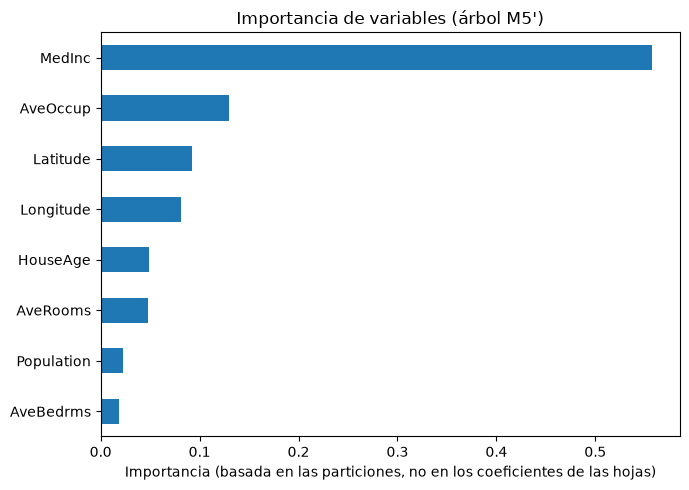

In [11]:
importances = pd.Series(m5_tree.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(7, 5))
importances.plot(kind="barh")
plt.xlabel("Importancia (basada en las particiones, no en los coeficientes de las hojas)")
plt.title("Importancia de variables (árbol M5')")
plt.tight_layout()
plt.show()

## 8. M5' vs. CART (regresión)

Con los mismos datos y sin restringir la profundidad, comparamos M5' contra un `DecisionTreeRegressor` (CART) estándar. La diferencia no está en qué tan bien particionan el espacio — ambos usan el mismo tipo de motor de árbol — sino en qué predicen en cada hoja: CART memoriza la media local (y con hojas muy pequeñas eso se acerca a sobreajustar el ruido de entrenamiento), mientras que M5' ajusta una recta que generaliza mejor incluso con regiones grandes.

In [12]:
cart_tree = DecisionTreeRegressor(random_state=42)
cart_tree.fit(X_train, y_train)
y_pred_cart = cart_tree.predict(X_test)

comparison = pd.DataFrame({
    "modelo": ["CART (DecisionTreeRegressor, constante en hojas)", "M5' (M5Prime, regresión lineal en hojas)"],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_cart)), rmse_m5],
    "MAE": [mean_absolute_error(y_test, y_pred_cart), mae_m5],
    "R2": [r2_score(y_test, y_pred_cart), r2_m5],
    "profundidad": [cart_tree.get_depth(), m5_tree.get_depth()],
    "hojas": [cart_tree.get_n_leaves(), m5_tree.get_n_leaves()],
})
comparison

,modelo,RMSE,MAE,R2,profundidad,hojas
0,"CART (DecisionTreeRegressor, constante en hojas)",0.703729,0.454679,0.622076,34,15854
1,"M5' (M5Prime, regresión lineal en hojas)",0.577042,0.358148,0.745898,27,3052


## 9. Poda y suavizado (la parte de M5' que más importa)

En M5' son **dos** mecanismos los que marcan la diferencia frente a un árbol de regresión sin podar: la **poda** (`use_pruning`, colapsa subárboles cuyo modelo lineal combinado no mejora significativamente el error) y el **suavizado** (`use_smoothing`, combina cada hoja con los modelos lineales de sus ancestros). Entrenamos las 4 combinaciones posibles para ver el efecto de cada una por separado.

In [13]:
resultados = []
for pruning in [False, True]:
    for smoothing in [False, True]:
        modelo = M5Prime(use_pruning=pruning, use_smoothing=smoothing, random_state=42)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        resultados.append({
            "poda (use_pruning)": pruning,
            "suavizado (use_smoothing)": smoothing,
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "profundidad": modelo.get_depth(),
            "hojas": modelo.get_n_leaves(),
        })

ablation = pd.DataFrame(resultados)
ablation

,poda (use_pruning),suavizado (use_smoothing),RMSE,profundidad,hojas
0,False,False,0.662609,28,6013
1,False,True,0.576704,28,6013
2,True,False,0.974119,27,3052
3,True,True,0.577042,27,3052


Dos lecturas quedan claras al comparar filas: (1) el **suavizado** por sí solo ya reduce el error de forma notable frente a no tener ninguno de los dos mecanismos activo — combinar el modelo de la hoja con los de sus ancestros corrige buena parte del ruido de una hoja pequeña; (2) la **poda sin suavizado** puede incluso empeorar el error (colapsar subárboles en un único modelo lineal, sin la corrección del suavizado, pierde la capacidad de adaptarse a sub-regiones). La configuración por defecto (poda **y** suavizado activos) es la que logra un árbol mucho más compacto —muchas menos hojas— con una precisión prácticamente igual a la del árbol sin podar, que es justamente el objetivo de podar: compactar sin sacrificar precisión.

## 10. Predecir sobre muestras nuevas

Evitamos inventar atributos (sería fácil salirse de los rangos realistas del dataset) y en su lugar tomamos 3 distritos reales del conjunto de prueba, nunca vistos durante el entrenamiento, y comparamos el valor real contra el predicho por el árbol M5' entrenado en la sección 4.

In [14]:
sample_positions = [0, 1, 2]  # tres distritos de prueba, elegidos arbitrariamente

for pos in sample_positions:
    real_usd = y_test[pos] * 100_000
    pred_usd = m5_tree.predict(X_test[pos].reshape(1, -1))[0] * 100_000
    atributos = dict(zip(feature_names, X_test[pos]))
    print(f"Real: ${real_usd:>10,.0f} | Predicho: ${pred_usd:>10,.0f}")
    print(f"  Atributos: {atributos}\n")

Real: $    47,700 | Predicho: $    51,890
  Atributos: {'MedInc': 1.6812, 'HouseAge': 25.0, 'AveRooms': 4.192200557103064, 'AveBedrms': 1.0222841225626742, 'Population': 1392.0, 'AveOccup': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01}

Real: $    45,800 | Predicho: $    77,285
  Atributos: {'MedInc': 2.5313, 'HouseAge': 30.0, 'AveRooms': 5.039383561643835, 'AveBedrms': 1.1934931506849316, 'Population': 1565.0, 'AveOccup': 2.6797945205479454, 'Latitude': 35.14, 'Longitude': -119.46}

Real: $   500,001 | Predicho: $   481,420
  Atributos: {'MedInc': 3.4801, 'HouseAge': 52.0, 'AveRooms': 3.977154724818276, 'AveBedrms': 1.185877466251298, 'Population': 1310.0, 'AveOccup': 1.3603322949117342, 'Latitude': 37.8, 'Longitude': -122.44}



## 11. Alternativas implementación de M5

Si `m5py` no encaja con el caso de uso, existen las siguientes alternativas:

- **Weka / Java:** `M5P` es la implementación de referencia de Wang y Witten, parte de [Weka](https://www.cs.waikato.ac.nz/ml/weka/) desde hace más de dos décadas y mucho más probada que `m5py`. Se puede usar desde Python con el puente [`python-weka-wrapper3`](https://github.com/fracpete/python-weka-wrapper3) (requiere JVM).
- **R:** el paquete `RWeka` expone `M5P()`, que llama a la misma implementación de Weka.
- **Python:** además de `m5py` (usado aquí), existen implementaciones de investigación menos mantenidas de "árboles lineales" con espíritu similar, como [`linear-tree`](https://github.com/cerlymarco/linear-tree), que ajusta un estimador de scikit-learn (no necesariamente OLS) en cada hoja — no sigue el algoritmo M5' exacto (usa reducción de varianza estándar, no SDR, y no implementa el suavizado de M5'), pero es una alternativa más activamente mantenida si solo necesitas la idea general de "modelo lineal por hoja".

Para trabajos de curso que solo necesitan demostrar *los conceptos* que M5/M5' introdujeron sobre CART (modelos lineales por hoja, poda basada en error, suavizado entre regiones), `m5py` con poda y suavizado activados —como se mostró arriba— es la forma más directa y fiel al algoritmo original de mostrarlo en Python.